In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('HR_data_2.csv')

In [3]:
# drop first column
df = df.drop(df.columns[0], axis=1)
df

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,78.663878,76.700,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.730000,0.9775,...,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,76.540732,76.610,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.360000,0.1900,...,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,78.173563,77.920,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.630000,0.3575,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,83.073688,83.880,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.465000,0.6500,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,72.281250,72.910,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.372500,0.3375,...,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,82.019065,78.830,8.794206,69.73,97.18,26244.705,-1.386324,0.251382,-0.517500,0.3525,...,3.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0
308,103.274248,104.625,14.208117,68.13,125.52,31523.695,-0.338091,-0.521254,-0.962500,1.0875,...,2.0,1.0,3.0,1.0,1.0,1.0,4.0,1.0,3.0,4.0
309,99.065000,97.490,10.079197,86.55,119.75,28235.230,-0.740136,0.629730,-0.657500,0.9175,...,1.0,1.0,3.0,1.0,3.0,1.0,3.0,1.0,3.0,4.0
310,91.793354,97.180,19.234169,60.90,120.67,28909.835,-1.229115,-0.181431,-0.717500,0.9800,...,2.0,1.0,3.0,1.0,3.0,1.0,4.0,1.0,4.0,4.0


In [4]:
# Missing value check
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])

rows_with_nan = df[df.isnull().any(axis=1)].index

print("Rows index with missing values: ")
print(rows_with_nan.tolist())

EDA_TD_P_RT     1
EDA_TD_P_ReT    1
inspired        2
attentive       1
afraid          1
active          1
determined      2
dtype: int64
Rows index with missing values: 
[104, 120, 122, 125, 272]


In [5]:
# Find all 'TD' features
features = [col for col in df.columns if 'TD' in col]
 
df_preprocessed = df.copy()

df_preprocessed[features] = df_preprocessed[features].astype(float)

# Individualized Imputation and Normalization
for ind in df['Individual'].unique():
    subset_idx = df[df['Individual'] == ind].index
    
    X_subset = df.loc[subset_idx, features]
    
    # --- A. Imputation ---
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_subset)
    
    # --- B. Normalization/ Standardization ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    df_preprocessed.loc[subset_idx, features] = X_scaled

df_preprocessed

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,0.369071,0.164578,0.551587,-0.125959,0.136489,-0.105352,-0.697423,0.079325,-0.309591,2.244211,...,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,-0.029258,0.146206,-1.028737,0.625407,-0.515190,0.433103,-0.065442,0.038070,0.774893,-1.093847,...,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,0.277082,0.413613,-0.997585,1.327072,-0.485014,-1.714475,-0.342241,-0.717414,-0.016487,-0.383847,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,1.196406,1.630212,0.513996,0.508463,0.370194,1.002815,-0.529486,-0.470299,0.467134,0.856003,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,-0.828390,-0.609065,-0.832135,-0.798387,-0.666071,-0.103196,0.267492,-1.150665,0.738255,-0.468623,...,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,-1.862176,-2.372509,-0.386103,-1.237028,-1.320204,-1.043763,-1.028818,0.389615,0.636494,-1.232420,...,3.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0
308,0.233661,0.592313,0.615715,-1.390765,0.366530,0.584951,1.656264,-1.466275,-1.385645,1.202876,...,2.0,1.0,3.0,1.0,1.0,1.0,4.0,1.0,3.0,4.0
309,-0.181386,-0.227769,-0.148322,0.379139,0.023113,-0.429631,0.626413,1.298415,0.000316,0.639610,...,1.0,1.0,3.0,1.0,3.0,1.0,3.0,1.0,3.0,4.0
310,-0.898396,-0.263399,1.545761,-2.085467,0.077869,-0.221497,-0.626122,-0.650013,-0.272332,0.846693,...,2.0,1.0,3.0,1.0,3.0,1.0,4.0,1.0,4.0,4.0


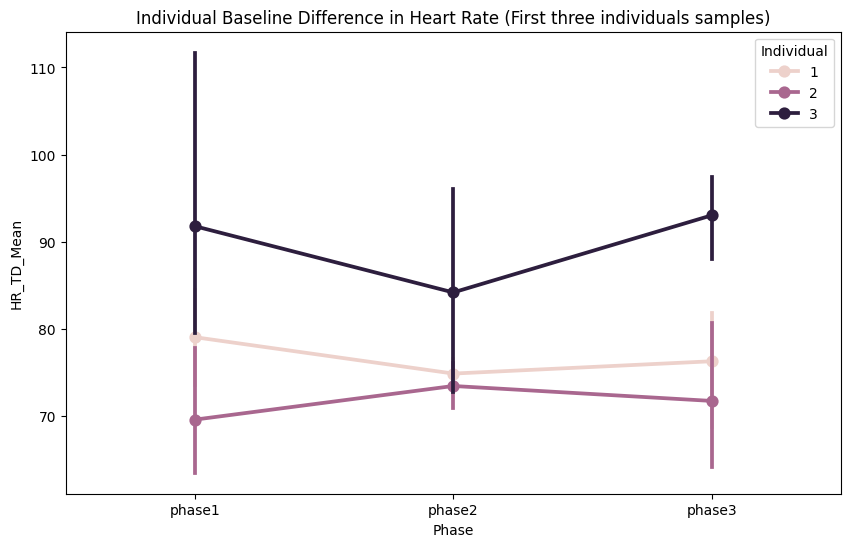

In [7]:
# Clear the space in the string space
df.columns = df.columns.str.strip()

### This section is to sample the first three individuals
### To kind of show that there are huge difference between body
### Heart Rate as ㄇㄔexample

import matplotlib.pyplot as plt
import seaborn as sns

test_individuals = df['Individual'].unique()[:3]
subset = df[df['Individual'].isin(test_individuals)].copy()
phase_order = ['phase1', 'phase2', 'phase3']
subset['Phase'] = pd.Categorical(subset['Phase'], categories=phase_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.pointplot(data=subset, x='Phase', y='HR_TD_Mean', hue='Individual')
plt.title('Individual Baseline Difference in Heart Rate (First three individuals samples)')
plt.show()

First two components explain 29.33% variation of total variance


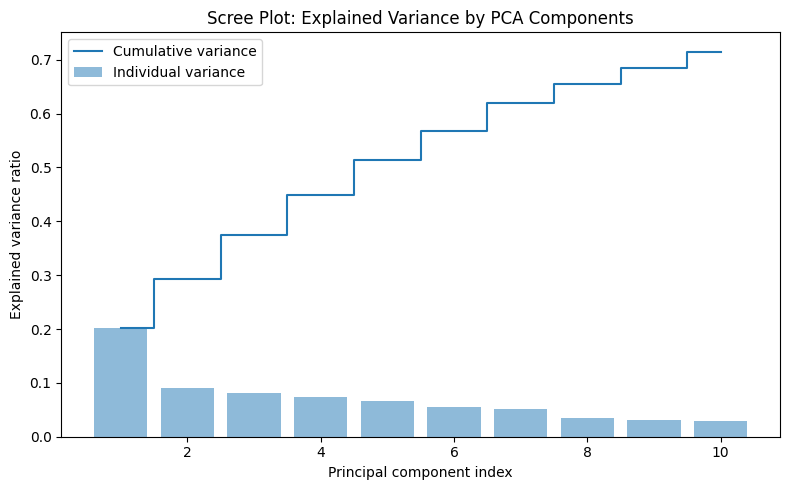

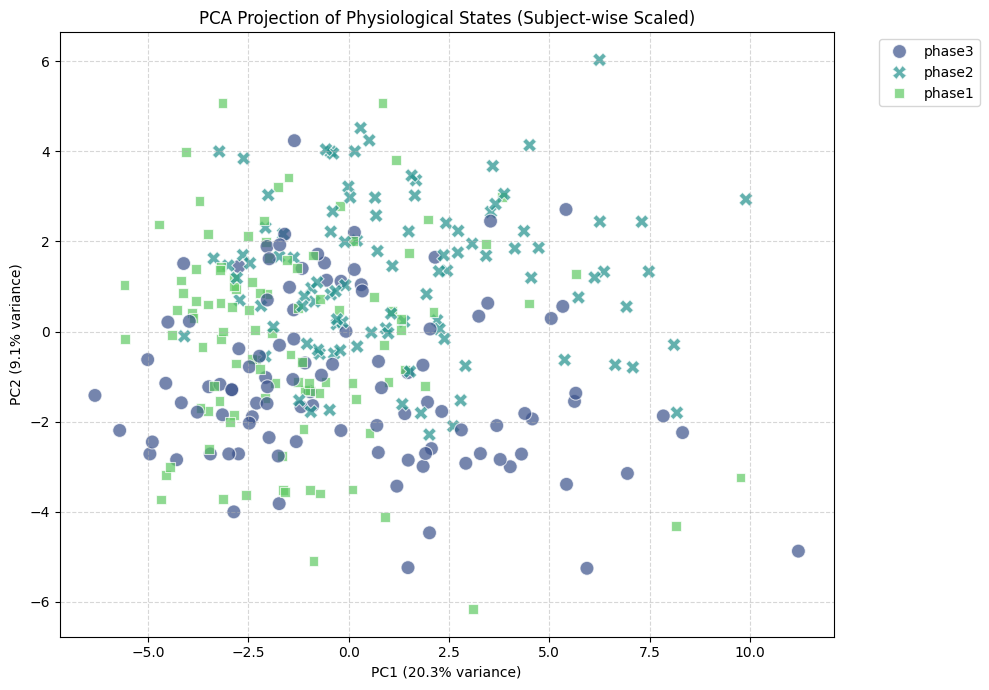

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10) # First observe first 10 features
pca_results = pca.fit_transform(df_preprocessed[features])

df_preprocessed['PC1'] = pca_results[:, 0]
df_preprocessed['PC2'] = pca_results[:, 1]

# Visualization: scree plot ()
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.bar(range(1, 11), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Individual variance')
plt.step(range(1, 11), exp_var_cumul, where='mid', label='Cumulative variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot: Explained Variance by PCA Components')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('pca_scree_plot.png')

# Visualization 2: project data points onto two major component
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_preprocessed, 
    x='PC1', y='PC2', 
    hue='Phase', 
    style='Phase',
    s=100, alpha=0.7, palette='viridis'
)
plt.title('PCA Projection of Physiological States (Subject-wise Scaled)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_phase_scatter.png')

print(f"First two components explain {exp_var_cumul[1]:.2%} variation of total variance")

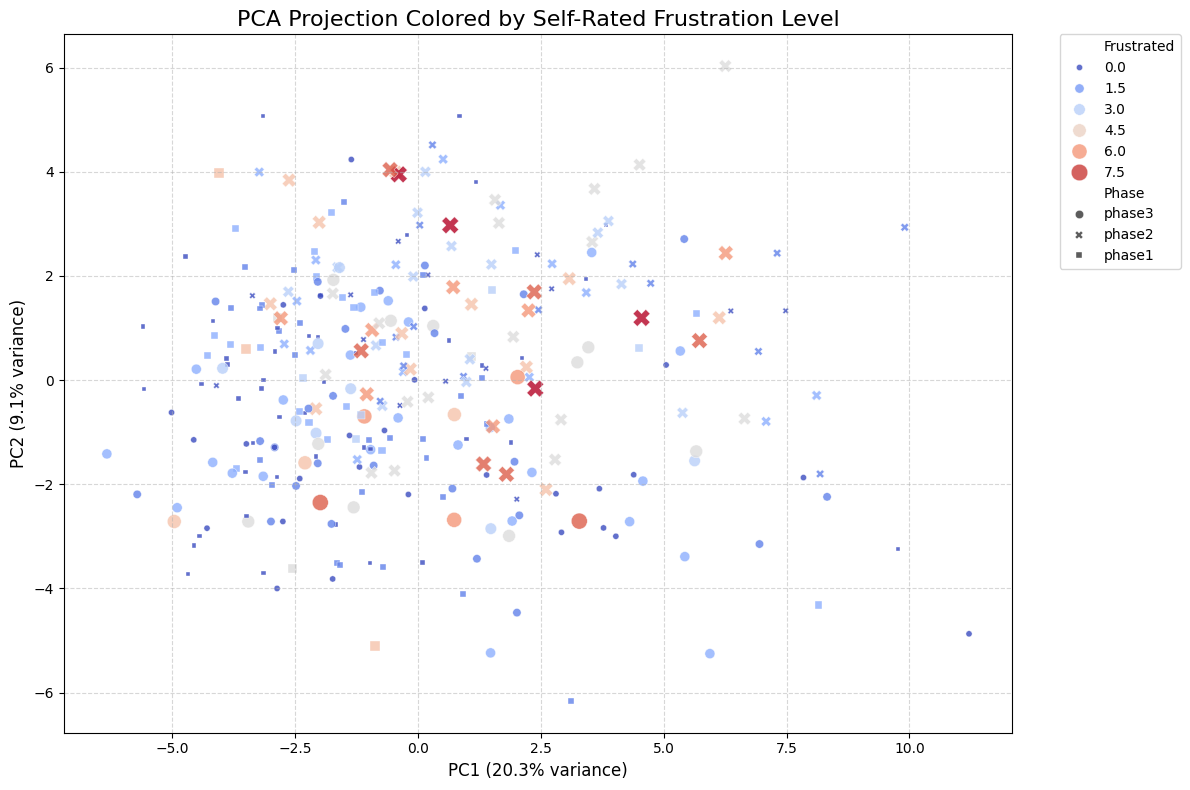